# Tarefas

- Pesquisar base de dados do enem
- Tirar amostra de 10% de usuarios
- Pegar a média de todos os usuários
- Comparar a média das notas dos homem e mulheres
- Comparar a médias das notas dos homes negros brancos pardos e indígenas
- Comparar a média das notas de mulheres negras brancas pardas e indígenas
- Graficos
- de cada materia


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
#Importando bilbiotecas

In [2]:
df = pd.read_csv('MICRODADOS_ENEM_2020.csv', sep = ';', encoding = 'ISO-8859-1')
#Buscando planilia
#Foi usado o 'ISO-8859-1', por apresentar error ao usar o utf-8.

In [3]:
df

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,200006271946,2020,11,F,1,2,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001195856,2020,11,M,2,3,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001943954,2020,4,F,2,3,2,2,0,2,...,B,A,A,B,A,A,A,A,A,A
3,200001908998,2020,2,M,1,3,1,2,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001634757,2020,4,F,1,3,2,1,1,1,...,A,A,A,B,A,B,B,A,A,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5783104,200003396891,2020,2,F,1,1,1,2,0,2,...,B,A,A,B,A,A,D,A,B,B
5783105,200006040822,2020,3,M,1,1,1,2,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5783106,200004928656,2020,3,F,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5783107,200006774808,2020,4,F,1,1,1,2,0,3,...,B,B,B,D,B,B,E,A,D,B


## Tratamento do DataFrame
- Excluindo colunas desnecessarias
- Tirando usuarios que não fizeram nenhuma etapa da prova
- Criando uma nova planilha 

In [4]:
print (list(df.columns))
#Mostrando a lista de colunas

['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH', 'TX_GABARITO_LC', 'TX_GABARITO_MT', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 

Excluindo colunas que não são necessarias

In [5]:
df = df.drop(columns = ['TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
                        'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO','CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 
                        'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC','CO_MUNICIPIO_PROVA', 
                        'CO_UF_PROVA', 'CO_PROVA_CN', 
                        'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC', 
                        'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH', 'TX_GABARITO_LC', 'TX_GABARITO_MT',
                        'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5',
                        'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013',
                        'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025','NU_ANO',
                       'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', ])

In [6]:
df
#Mostrando a lista para ver como ficou

,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,200006271946,F,2,0,0,0,0,NaN,NaN,NaN,NaN,NaN
1,200001195856,M,3,1,1,1,1,604.1,661.7,595.3,711.3,580.0
2,200001943954,F,3,0,0,0,0,NaN,NaN,NaN,NaN,NaN
3,200001908998,M,3,1,1,1,1,620.8,675.0,624.2,759.4,760.0
4,200001634757,F,3,0,0,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5783104,200003396891,F,1,1,1,1,1,508.3,661.4,658.3,725.7,900.0
5783105,200006040822,M,1,1,1,1,1,570.5,646.1,607.2,719.5,660.0
5783106,200004928656,F,1,1,1,1,1,418.8,597.5,674.5,648.1,660.0
5783107,200006774808,F,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN


In [7]:
df = df.loc[(df['TP_PRESENCA_CH'] == 1) |
                        (df['TP_PRESENCA_CN'] == 1) |
                        (df['TP_PRESENCA_LC'] == 1) |
                        (df['TP_PRESENCA_MT'] == 1)]
#Removendo linhas em que TODAS elas correspondem com valor 0

In [8]:
df
#Mostrando nova coluna

,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
1,200001195856,M,3,1,1,1,1,604.1,661.7,595.3,711.3,580.0
3,200001908998,M,3,1,1,1,1,620.8,675.0,624.2,759.4,760.0
5,200003132410,F,3,1,1,1,1,498.1,604.7,505.4,526.7,700.0
7,200001334237,M,1,1,1,1,1,604.6,604.8,562.1,753.2,600.0
8,200006762554,F,3,1,1,1,1,439.7,383.5,486.2,448.5,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5783103,200001819135,M,1,1,1,1,1,547.3,613.3,596.4,469.1,660.0
5783104,200003396891,F,1,1,1,1,1,508.3,661.4,658.3,725.7,900.0
5783105,200006040822,M,1,1,1,1,1,570.5,646.1,607.2,719.5,660.0
5783106,200004928656,F,1,1,1,1,1,418.8,597.5,674.5,648.1,660.0


## Tirando 10% de toda a planilha

In [9]:
conta = 2762899/10
print(conta)
#Fazendo a conta para tirar 10% do valor total

276289.9


In [10]:
df2 = df.sample(276289).reset_index()
#Pegando aleatoriamente linhas da tabela e inserindo em uma variavel nova

In [11]:
df2

,index,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,948503,200002646960,F,1,1,1,1,1,565.7,570.0,564.3,566.9,860.0
1,2028796,200005751828,M,1,1,1,1,1,621.4,682.2,624.5,799.9,960.0
2,3809483,200006628132,M,1,1,1,1,1,695.9,716.9,659.4,908.1,600.0
3,2421667,200003710307,M,1,1,1,1,1,477.3,465.5,548.4,491.4,720.0
4,569082,200004650265,F,3,1,1,1,1,647.2,623.1,577.3,454.0,920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
276284,4477340,200001666280,F,3,1,1,1,1,501.8,488.9,531.3,432.3,380.0
276285,1861955,200004236958,F,1,1,1,1,1,376.5,348.4,384.0,369.2,540.0
276286,3286145,200006290682,F,1,1,1,1,1,474.5,447.7,424.7,411.1,540.0
276287,194697,200001562191,M,1,1,1,1,1,521.6,560.7,515.2,493.3,560.0


## Tirando a média de todos os usuários

In [12]:
df2['MEDIA_TOTAL'] = (df2['NU_NOTA_CN'] + df2['NU_NOTA_CH'] + df2['NU_NOTA_LC']
+ df2['NU_NOTA_MT'] + df2['NU_NOTA_REDACAO']) / 5
#Tirando a média de todas as pessoas.

In [13]:
df2
#Mostrando

,index,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,MEDIA_TOTAL
0,948503,200002646960,F,1,1,1,1,1,565.7,570.0,564.3,566.9,860.0,625.38
1,2028796,200005751828,M,1,1,1,1,1,621.4,682.2,624.5,799.9,960.0,737.60
2,3809483,200006628132,M,1,1,1,1,1,695.9,716.9,659.4,908.1,600.0,716.06
3,2421667,200003710307,M,1,1,1,1,1,477.3,465.5,548.4,491.4,720.0,540.52
4,569082,200004650265,F,3,1,1,1,1,647.2,623.1,577.3,454.0,920.0,644.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276284,4477340,200001666280,F,3,1,1,1,1,501.8,488.9,531.3,432.3,380.0,466.86
276285,1861955,200004236958,F,1,1,1,1,1,376.5,348.4,384.0,369.2,540.0,403.62
276286,3286145,200006290682,F,1,1,1,1,1,474.5,447.7,424.7,411.1,540.0,459.60
276287,194697,200001562191,M,1,1,1,1,1,521.6,560.7,515.2,493.3,560.0,530.16


## Comparando a média de notas de homens e mulheres

In [14]:
dff = df2[df2['TP_SEXO']=='F']
#Separando uma variavel só com usuarios Femininas

In [15]:
dfm = df2[df2['TP_SEXO'] == 'M']
#Separando uma variavel só com usuarios Masculinos

### Mostrando a quantidade total de homens e mulheres da tabela

In [16]:
frequencia = df2['TP_SEXO'].value_counts()
print(frequencia)

F    166788
M    109501
Name: TP_SEXO, dtype: int64


### Grafico da média total
O grafico a baixo, representa a média das notas entre o sexo masculino e feminino.
E percebe-se que as notas masculinas foram as melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

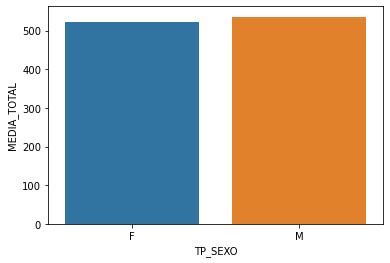

In [17]:
grafico1 = sns.barplot(x = df2['TP_SEXO'], y = df2['MEDIA_TOTAL'], estimator = np.mean, data = df2)

### Grafico das notas em Ciências da Natureza
O gráfico a baixo, representa a média de notas em ciências da natureza.
E percebe-se que as notas masculinas foram melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

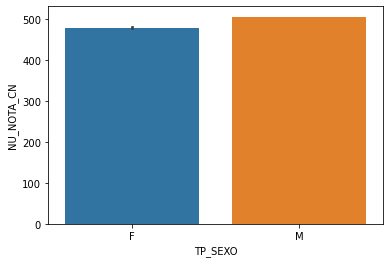

In [18]:
grafico2 = sns.barplot(x = df2['TP_SEXO'], y = df2['NU_NOTA_CN'], estimator = np.mean, data = df2)

### Grafico das notas em Ciências Humanas
O gráfico a baixo,representa a média das notas em ciências humanas.
E percebe-se que as notas masculinas foram melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

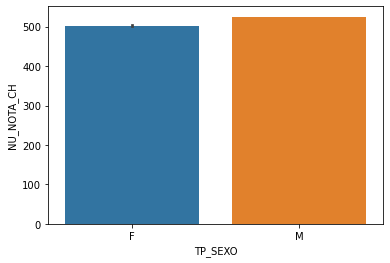

In [19]:
grafico3 = sns.barplot(x = df2['TP_SEXO'], y = df2['NU_NOTA_CH'], estimator = np.mean, data = df2)

### Grafico das notas em Linguagens e Códigos
O gráfico a baixo,representa a média das notas em Linguagens e Códigos.
E percebe-se que as notas masculinas foram melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

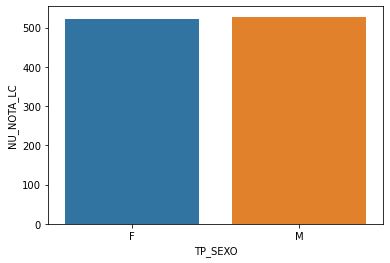

In [20]:
grafico4 = sns.barplot(x = df2['TP_SEXO'], y = df2['NU_NOTA_LC'], estimator = np.mean, data = df2)

### Gráfico das notas em Matemática
O gráfico a baixo, representa a média das notas em Matemática.
E percebe-se que as notas masculinas foram melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

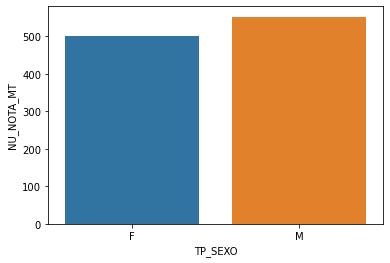

In [21]:
grafico5 = sns.barplot(x = df2['TP_SEXO'], y = df2['NU_NOTA_MT'], estimator = np.mean, data = df2)

### Gráfico das notas em Redação
O gráfico a baixo, representa a média das notas em Redação.
E percebe-se que as notas Femininas foram melhores.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinado sexo que fizeram a prova.

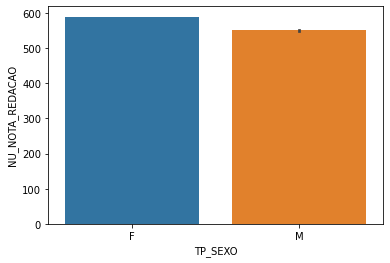

In [22]:
grafico6 = sns.barplot(x = df2['TP_SEXO'], y = df2['NU_NOTA_REDACAO'], estimator = np.mean, data = df2)

## Comparando a média das notas de homens:Não Informado(0), Branco(1), Preto(2), Parda(3), Amarela(4) e Indígena(5).

In [23]:
frequencia_m = dfm['TP_COR_RACA'].value_counts(ascending=False)
print(frequencia_m)

3    48813
1    41986
2    13984
4     2064
0     2057
5      597
Name: TP_COR_RACA, dtype: int64


### Grafico da média total
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

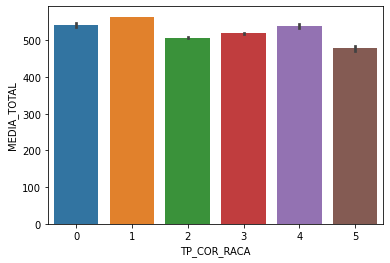

In [24]:
grafico7 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['MEDIA_TOTAL'], estimator = np.mean, data = dfm)

### Grafico das notas em Ciências da Natureza
O grafico a baixo mostra a média da nota de ciências da natureza das pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

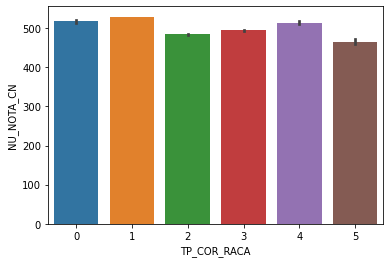

In [25]:
grafico8 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['NU_NOTA_CN'], estimator = np.mean, data = dfm)

### Grafico das notas em Ciências Humanas
O grafico a baixo mostra a média da nota de Ciências Humanas de pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

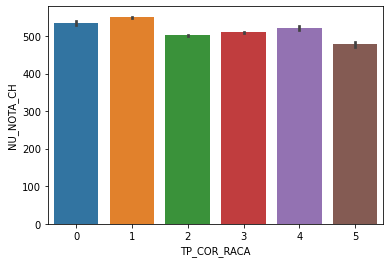

In [26]:
grafico9 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['NU_NOTA_CH'], estimator = np.mean, data = dfm)

### Grafico das notas em Linguagens e Códigos
O grafico a baixo mostra a média da nota de Linguagens e Códigos de pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

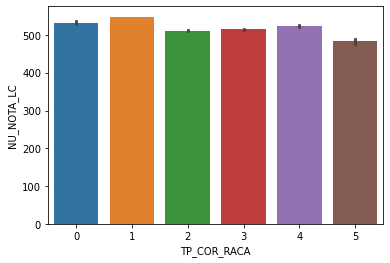

In [27]:
grafico10 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['NU_NOTA_LC'], estimator = np.mean, data = dfm)

### Gráfico das notas em Matemática
O grafico a baixo mostra a média da nota de Matemática de pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

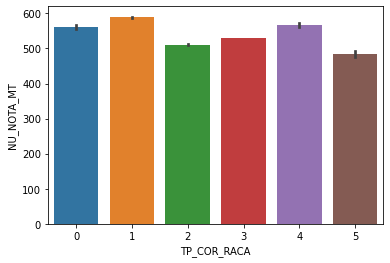

In [28]:
grafico11 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['NU_NOTA_MT'], estimator = np.mean, data = dfm)

### Gráfico das notas em Redação
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados masculinas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

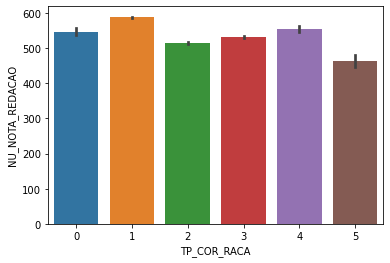

In [29]:
grafico12 = sns.barplot(x = dfm['TP_COR_RACA'], y = dfm['NU_NOTA_REDACAO'], estimator = np.mean, data = dfm)

## Comparando a média das notas de mulheres:Não Informado(0), Branco(1), Preto(2), Parda(3), Amarela(4) e Indígena(5).

In [30]:
frequencia_f = dff['TP_COR_RACA'].value_counts(ascending=False)
print(frequencia_f)
#Quantidade de participantes de cada cor/raça

3    76184
1    62519
2    19833
4     4131
0     3222
5      899
Name: TP_COR_RACA, dtype: int64


### Grafico da média total
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

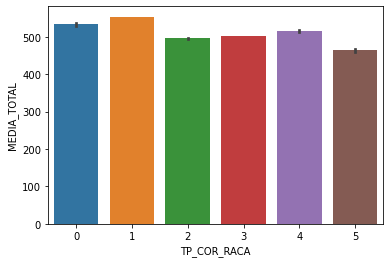

In [31]:
grafico13 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['MEDIA_TOTAL'], estimator = np.mean, data = dff)

### Grafico das notas em Ciências da Natureza
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

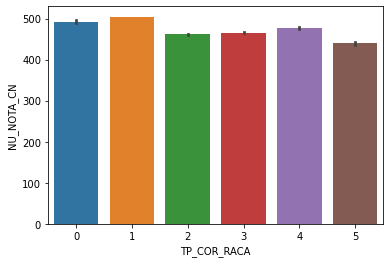

In [32]:
grafico14 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['NU_NOTA_CN'], estimator = np.mean, data = dff)

### Grafico das notas em Ciências Humanas
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

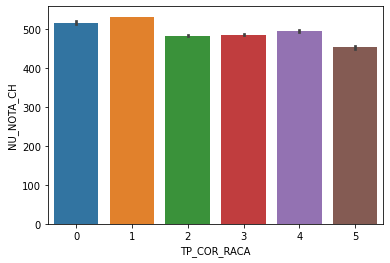

In [33]:
grafico15 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['NU_NOTA_CH'], estimator = np.mean, data = dff)

### Grafico das notas em Linguagens e Códigos
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

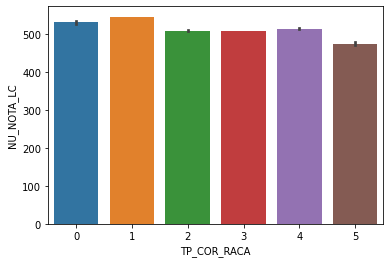

In [34]:
grafico16 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['NU_NOTA_LC'], estimator = np.mean, data = dff)

### Gráfico das notas em Matemática
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

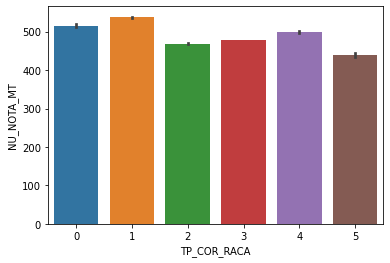

In [35]:
grafico17 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['NU_NOTA_MT'], estimator = np.mean, data = dff)

### Gráfico das notas em Redação
O grafico a baixo mostra a média da nota de Redação de pessoas de cor/raça autodeclarados femininas, nota-se que as pessoas brancas tiveram a média maior.
OBSERVAÇÃO:Prestar atenção na diferença de participantes de determinada cor/raça que fizeram a prova.

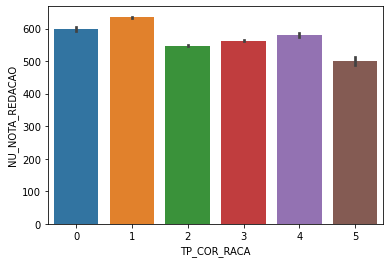

In [36]:
grafico18 = sns.barplot(x = dff['TP_COR_RACA'], y = dff['NU_NOTA_REDACAO'], estimator = np.mean, data = dff)